In [532]:
import numpy as np
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
import cv2 
import matplotlib.pyplot as plt

In [533]:
dataset_train_loc = "./dataset/mnist_train.csv"
dataset_test_loc = "./dataset/mnist_test.csv"
dataset_fonts_loc = "./dataset/TMNIST_Data.csv"
amt_test = 10000
amt_train = 60000

image_loc = "../images"

In [534]:
X_TEST = []
Y_TEST = []
with open(dataset_test_loc) as data:
    data.readline().split(",")
    string = data.readline().strip().split(",")
    counter = 0
    while len(string) != 1 and string[0] != '' and counter != amt_test:
        Y_TEST.append(int(string[0]))
        pixel_values = [int(i) for i in string[1:]]
        X_TEST.append(np.asarray(pixel_values))
        string = data.readline().strip().split(",")
        counter += 1
    
X_TEST = np.asarray(X_TEST, dtype=object)
Y_TEST = np.asarray(Y_TEST, dtype=int)
print(X_TEST.shape, len(Y_TEST), counter)

(10000, 784) 10000 10000


In [535]:
X_TRAIN = []
Y_TRAIN = []
with open(dataset_train_loc) as data:
    data.readline().split(",")
    string = data.readline().strip().split(",")
    counter = 0
    while len(string) != 1 and string[0] != '' and counter != amt_train:
        Y_TRAIN.append(int(string[0]))
        pixel_values = [int(i) for i in string[1:]]
        X_TRAIN.append(np.array(pixel_values, dtype=int))
        string = data.readline().strip().split(",")
        counter += 1
        
X_TRAIN = np.asarray(X_TRAIN, dtype=object)
Y_TRAIN = np.asarray(Y_TRAIN, dtype=int)
print(X_TRAIN.shape, len(Y_TRAIN), counter)

(60000, 784) 60000 60000


In [536]:

def generate_noise_images(num_images, image_size=784):
    # mix of completely random noise and blank images
    random_noise = np.random.rand(num_images // 2, image_size)
    blank_images = np.zeros((num_images - num_images // 2, image_size))
    return np.vstack([random_noise, blank_images])

num_noise_train = 2000
num_noise_test = 500

X_noise_train = generate_noise_images(num_noise_train)
y_noise_train = np.full(num_noise_train, 10)  # label 10 = non-digit

X_noise_test = generate_noise_images(num_noise_test)
y_noise_test = np.full(num_noise_test, 10)

X_TRAIN = np.vstack([X_TRAIN, X_noise_train])
Y_TRAIN = np.hstack([Y_TRAIN, y_noise_train])

X_TEST = np.vstack([X_TEST, X_noise_test])
Y_TEST = np.hstack([Y_TEST, y_noise_test])

In [537]:
FONT_DIGITS_X = []
FONT_DIGITS_Y = []

def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

with open(dataset_fonts_loc) as data:
    data.readline().split(",")
    string = data.readline().strip().split(",")
    # counter = 0
    for line in data:
        test = int(string[1])
        FONT_DIGITS_Y.append(test)
        pixel_values = [int(i) for i in string[2:]]
        FONT_DIGITS_X.append(np.array(pixel_values, dtype=int))
        string = line.strip().split(",")
        
FONT_DIGITS_X = np.asarray(FONT_DIGITS_X, dtype=object)
FONT_DIGITS_Y = np.asarray(FONT_DIGITS_Y, dtype=int)


Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    FONT_DIGITS_X, FONT_DIGITS_Y, test_size=0.45, random_state=42
)

print(X_TRAIN.shape, Y_TRAIN.shape, X_TEST.shape, Y_TEST.shape)

X_TRAIN = np.concatenate((Xc_train, X_TRAIN), axis=0)
Y_TRAIN = np.concatenate((yc_train, Y_TRAIN), axis=0)
X_TEST = np.concatenate((Xc_test,X_TEST), axis=0)
Y_TEST = np.concatenate((yc_test,Y_TEST), axis=0)


# X_TRAIN, Y_TRAIN = unison_shuffled_copies(X_TRAIN, Y_TRAIN)
# X_TEST, Y_TEST = unison_shuffled_copies(X_TEST, Y_TEST)

print(X_TRAIN.shape, Y_TRAIN.shape, X_TEST.shape, Y_TEST.shape)


(62000, 784) (62000,) (10500, 784) (10500,)
(78444, 784) (78444,) (23955, 784) (23955,)


Accuracy: 0.9715299519933208
(78444, 784) (78444,) (23955, 784) (23955,)


In [540]:
def resize_and_pad(img, size=28, pad=4):
    h, w = img.shape
    scale = (size - pad*2) / max(h, w)
    new_h, new_w = int(h * scale), int(w * scale)
    resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
    
    # center pad
    padded = np.zeros((size, size), dtype=np.uint8)
    y_off = (size - new_h) // 2
    x_off = (size - new_w) // 2
    padded[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return resized

In [541]:
def crop_and_resize(img, size=28, pad=4):
    # Find bounding box
    coords = cv2.findNonZero(img)
    x, y, w, h = cv2.boundingRect(coords)
    digit = img[y:y+h, x:x+w]

    # Scale keeping aspect ratio
    if h > w:
        new_h = size - pad*2
        new_w = int(w * (new_h / h))
    else:
        new_w = size - pad*2
        new_h = int(h * (new_w / w))
    digit = cv2.resize(digit, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    # Pad into 28x28
    padded = np.zeros((size, size), dtype=np.uint8)
    y_off = (size - new_h) // 2
    x_off = (size - new_w) // 2
    padded[y_off:y_off+new_h, x_off:x_off+new_w] = digit
    return padded

In [542]:
def extract_inner_digit_area(img, target_size=28, min_area=50, max_area_ratio=0.9):
    """
    Extract digit by filtering contours based on area.
    
    Parameters:
        img : np.ndarray (grayscale or BGR)
        target_size : output size (default 28x28)
        min_area : minimum contour area to be considered a digit
        max_area_ratio : fraction of total image area (contours larger are discarded)
    """
    # Ensure grayscale
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()

    # # Invert so digit is white, background dark (for thresholding)
    # inverted = cv2.bitwise_not(gray)

    # # Binary threshold (Otsu)
    # _, binary = cv2.threshold(inverted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Find contours
    contours, _ = cv2.findContours(gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return cv2.resize(gray, (target_size, target_size))

    # Filter contours by area
    h, w = gray.shape
    max_area = h * w * max_area_ratio
    valid_contours = [c for c in contours if min_area < cv2.contourArea(c) < max_area]

    if not valid_contours:
        return cv2.resize(gray, (target_size, target_size))

    # Choose largest valid contour (assume digit is biggest valid one)
    digit_contour = max(valid_contours, key=cv2.contourArea)

    # Bounding box around digit contour
    x, y, w, h = cv2.boundingRect(digit_contour)
    cropped = gray[y:y+h, x:x+w]

    # Resize back to 28x28
    resized = cv2.resize(cropped, (target_size, target_size), interpolation=cv2.INTER_AREA)

    return resized

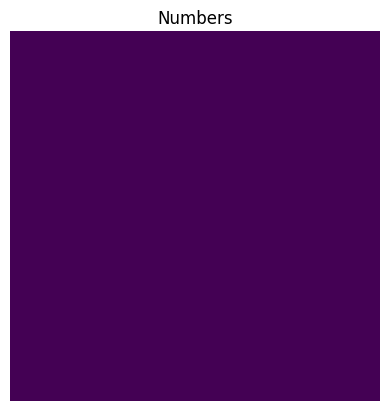

In [ ]:
# Test with an actual image
thickness = 5
image = cv2.imread(image_loc+'/1.png')

cropped = image[thickness:-thickness, thickness:-thickness] # top : bottom, left:right
gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
gray = cv2.resize(gray, (28, 28), interpolation=cv2.INTER_NEAREST)
gray = cv2.bitwise_not(gray)
 
# gray = cv2.blur(gray, (1,1))
_, thresh1 = cv2.threshold(gray,120,255,cv2.THRESH_BINARY)
gray = cv2.blur(thresh1, (1,1))
_, gray = cv2.threshold(gray,180,255,cv2.THRESH_BINARY)

thresh1 = cv2.adaptiveThreshold(gray, 255, 
                               cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
                               cv2.THRESH_BINARY, 11, 2)

thresh1 = extract_inner_digit_area(gray)
# # --- Compute center of mass ---
# M = cv2.moments(thresh1)
# if M["m00"] != 0:
#     cx = int(M["m10"] / M["m00"])
#     cy = int(M["m01"] / M["m00"])
# else:
#     cx, cy = 28//2, 28//2  # fallback

# # --- Shift so COM is at image center ---
# shift_x = 28//2 - cx
# shift_y = 28//2 - cy
# M_shift = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
# centered = cv2.warpAffine(gray, M_shift, (28, 28), borderValue=0)

# gray = centered
# plt.imshow(centered)
plt.imshow(thresh1)
plt.title('Numbers')
plt.axis('off') # Optional: turns off axis labels and ticks
plt.show()

NOTE:
For each cell there are residual cell barriers that are present in the image that are confusing the KNN algorithm. 

I wonder if the neural network is better at filtering through these noises?
--> Do this later when I have time


Nope, the actual problem was that the number was not at the center of the canvas so knn had some difficulty in detecting it.

In [545]:
pca = PCA(n_components=40)  # reduce to 50 dimensions
X_train_pca = pca.fit_transform(X_TRAIN)
X_test_pca = pca.transform(X_TEST)


# scaler = StandardScaler()
# print(X_TRAIN.shape, np.unique(Y_TRAIN))
# X_train = scaler.fit_transform(X_TRAIN)
# X_test = scaler.transform(X_TEST)

knn = KNeighborsClassifier(n_neighbors=7)  # k=3
knn.fit(X_train_pca, Y_TRAIN)

y_pred = knn.predict(X_test_pca)
print("Accuracy:", accuracy_score(Y_TEST, y_pred))
print(X_TRAIN.shape, Y_TRAIN.shape, X_TEST.shape, Y_TEST.shape)
if accuracy_score(Y_TEST , y_pred) > 0.9:
    joblib.dump(knn, "digit_classifier.pkl")
    joblib.dump(pca, "digit_pca.pkl")

Accuracy: 0.9715299519933208
(78444, 784) (78444,) (23955, 784) (23955,)


`

In [546]:
# Apply the same PCA transformation
gray_np = np.asarray(gray)
g_flat = [gray_np.flatten()]

print(gray_np.flatten().shape)
X_new_pca = pca.transform(g_flat)


final_test = knn.predict_proba(X_new_pca)
final_p = knn.predict(X_new_pca)

print(final_test, final_p)

(784,)
[[0.         0.14285714 0.         0.         0.42857143 0.
  0.         0.         0.         0.42857143 0.        ]] [4]
